In [1]:
# Multi-Stage Pottery Type Classification using DINOv2
# Stage 1: body vs everything else (base+rim+appendages)
# Stage 2: base vs rim vs appendage
# Stage 3: GPT-4o for appendage subtypes (experimental)

import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import joblib
import time
import glob
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import base64
from io import BytesIO

# Import transformers for DINOv2
try:
    from transformers import AutoModel, AutoImageProcessor
    TRANSFORMERS_AVAILABLE = True
    print("✓ Hugging Face transformers available")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠ Hugging Face transformers not available")
    print("Install with: pip install transformers")
    raise ImportError("transformers library is required. Install with: pip install transformers")

# Import XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available (optional)")
    print("Install with: pip install xgboost")

# Azure OpenAI (optional for Stage 3)
try:
    from openai import AzureOpenAI
    AZURE_OPENAI_AVAILABLE = True
    print("✓ Azure OpenAI SDK available")
except ImportError:
    AZURE_OPENAI_AVAILABLE = False
    print("⚠ Azure OpenAI SDK not available (needed for Stage 3)")
    print("Install with: pip install openai")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\nLibraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


✓ Hugging Face transformers available
✓ XGBoost available
✓ Azure OpenAI SDK available

Libraries imported successfully!
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


Loading pottery type images...
Found 334 base images
Error loading data/type\base\165-1-3000.png: image file is truncated
Found 1828 body images
Found 1861 rim images
Found 4 lid images
Found 9 rim-handle images
Found 9 spout images
Found 30 rounded images
Found 20 body-decorated images
Found 3 tile images

Dataset loaded successfully!
Total images: 4097

Class distribution (for Stage 1 & 2):
  appendage: 75
  base: 333
  body: 1828
  rim: 1861

Original class distribution (for Stage 3):
  base: 333
  body: 1828
  body-decorated: 20
  lid: 4
  rim: 1861
  rim-handle: 9
  rounded: 30
  spout: 9
  tile: 3


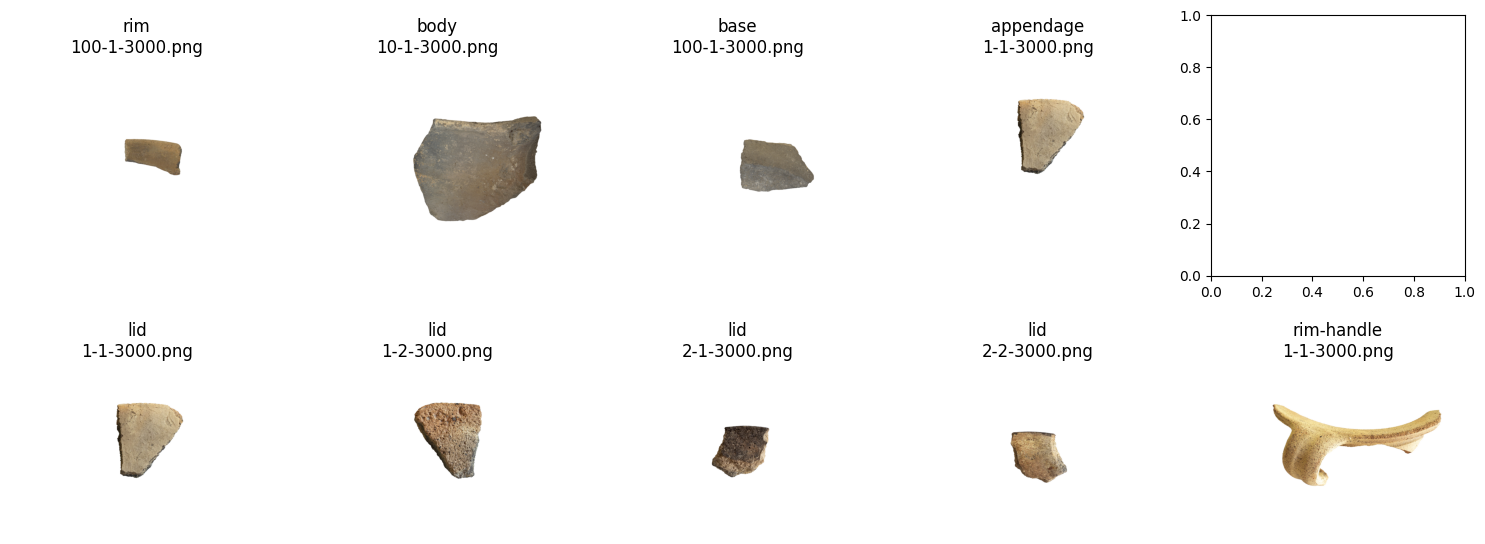

In [2]:
# 1. Data Loading and Preprocessing
# Load transparent pottery images and convert RGBA to RGB with data augmentation

def convert_rgba_to_rgb(image):
    """Convert RGBA to RGB with white background"""
    if image.mode == 'RGBA':
        # Create white background
        background = Image.new('RGB', image.size, (255, 255, 255))
        background.paste(image, mask=image.split()[-1])  # Use alpha channel as mask
        return background
    elif image.mode != 'RGB':
        return image.convert('RGB')
    return image

def load_type_images(data_dir="data/type"):
    """Load pottery type images from directory structure"""
    images = []
    labels = []
    filenames = []
    original_labels = []  # Keep track of original class names
    
    # Define class mapping
    class_mapping = {
        'base': 'base',
        'body': 'body',
        'rim': 'rim',
        'appendage/lid': 'lid',
        'appendage/rim-handle': 'rim-handle',
        'appendage/spout': 'spout',
        'appendage/rounded': 'rounded',
        'appendage/body-decorated': 'body-decorated',
        'appendage/tile': 'tile'
    }
    
    # Main classes
    main_classes = ['base', 'body', 'rim']
    
    # Appendage classes
    appendage_classes = ['lid', 'rim-handle', 'spout', 'rounded', 'body-decorated', 'tile']
    
    print("Loading pottery type images...")
    
    # Load main classes
    for class_name in main_classes:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} not found, skipping...")
            continue
            
        files = glob.glob(os.path.join(class_dir, "*.png"))
        print(f"Found {len(files)} {class_name} images")
        
        for file_path in sorted(files):
            try:
                img = Image.open(file_path)
                img = convert_rgba_to_rgb(img)
                images.append(img)
                labels.append(class_name)
                original_labels.append(class_name)
                filenames.append(os.path.basename(file_path))
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    # Load appendage classes
    for class_name in appendage_classes:
        class_dir = os.path.join(data_dir, "appendage", class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} not found, skipping...")
            continue
            
        files = glob.glob(os.path.join(class_dir, "*.png"))
        print(f"Found {len(files)} {class_name} images")
        
        for file_path in sorted(files):
            try:
                img = Image.open(file_path)
                img = convert_rgba_to_rgb(img)
                images.append(img)
                labels.append('appendage')  # Combine all appendages for Stage 2
                original_labels.append(class_name)  # Keep original for Stage 3
                filenames.append(os.path.basename(file_path))
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return images, labels, original_labels, filenames

# Load the dataset
images, labels, original_labels, filenames = load_type_images()

print(f"\nDataset loaded successfully!")
print(f"Total images: {len(images)}")

# Print class distribution
from collections import Counter
label_counts = Counter(labels)
print("\nClass distribution (for Stage 1 & 2):")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count}")

original_counts = Counter(original_labels)
print("\nOriginal class distribution (for Stage 3):")
for label, count in sorted(original_counts.items()):
    print(f"  {label}: {count}")

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_indices = []
unique_labels = list(set(labels))
for i, label in enumerate(unique_labels[:5]):
    # Get first image of each class
    idx = labels.index(label)
    sample_indices.append(idx)

# Show samples
for i, idx in enumerate(sample_indices[:5]):
    row = 0
    col = i
    axes[row, col].imshow(images[idx])
    axes[row, col].set_title(f"{labels[idx]}\n{filenames[idx][:30]}")
    axes[row, col].axis('off')

# Show some appendage examples
appendage_indices = [i for i, lbl in enumerate(original_labels) if lbl in ['lid', 'rim-handle', 'spout']]
for i, idx in enumerate(appendage_indices[:5]):
    row = 1
    col = i
    if col < 5:
        axes[row, col].imshow(images[idx])
        axes[row, col].set_title(f"{original_labels[idx]}\n{filenames[idx][:30]}")
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()



Creating augmentation plan (memory-efficient)...
  Main class augmentation factor: 2x
  Appendage class augmentation factor: 5x

Augmentation plan complete!
  Original images: 4097
  Total augmented samples: 8344
  Augmentation ratio: 2.04x

Showing sample augmentations (for visualization only)...


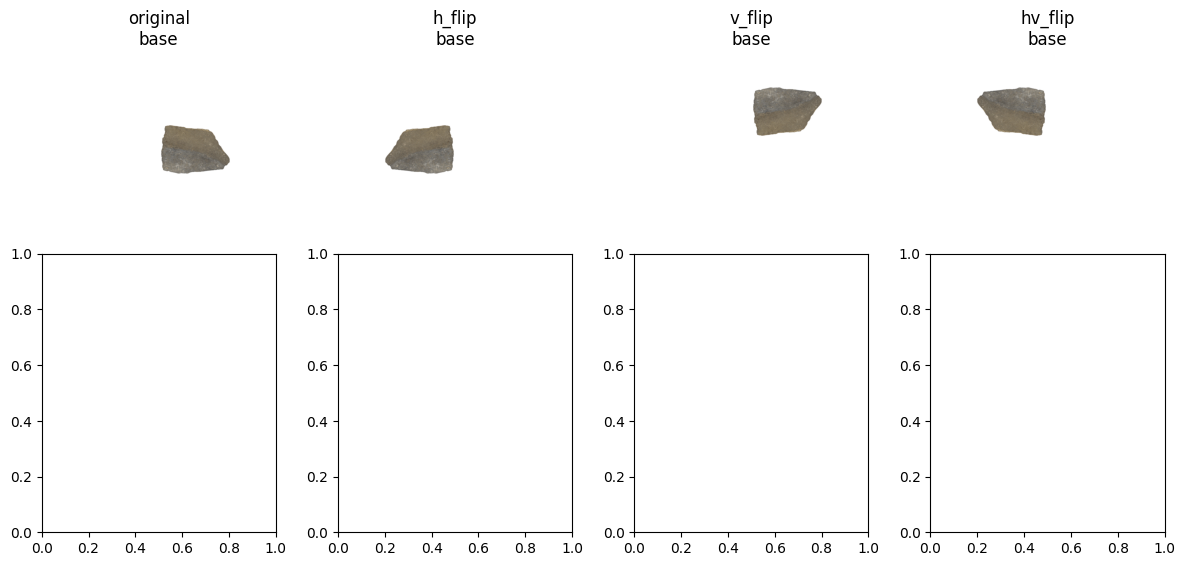


✓ Augmentation metadata created (memory-efficient)
  Images will be augmented on-the-fly during feature extraction


In [3]:
# 2. Data Augmentation - Memory Efficient
# Create augmentation metadata instead of storing all augmented images in memory
# Augmentations will be applied on-the-fly during feature extraction

def apply_augmentation(image, aug_type):
    """Apply a single augmentation transform to an image"""
    if aug_type == 'original' or aug_type == 'none':
        return image.copy()
    elif aug_type == 'horizontal' or aug_type == 'h_flip':
        return image.transpose(Image.FLIP_LEFT_RIGHT)
    elif aug_type == 'vertical' or aug_type == 'v_flip':
        return image.transpose(Image.FLIP_TOP_BOTTOM)
    elif aug_type == 'both' or aug_type == 'hv_flip':
        img_h = image.transpose(Image.FLIP_LEFT_RIGHT)
        return img_h.transpose(Image.FLIP_TOP_BOTTOM)
    else:
        return image.copy()

def create_augmentation_metadata(images, labels, original_labels, filenames,
                                 main_class_aug_factor=2, appendage_aug_factor=5):
    """Create augmentation metadata without storing augmented images in memory"""
    augmentation_plan = []  # List of (original_idx, aug_type) tuples
    
    print(f"\nCreating augmentation plan (memory-efficient)...")
    print(f"  Main class augmentation factor: {main_class_aug_factor}x")
    print(f"  Appendage class augmentation factor: {appendage_aug_factor}x")
    
    for i, (img, label, orig_label, filename) in enumerate(zip(images, labels, original_labels, filenames)):
        # Determine augmentation types based on class
        if label == 'appendage':
            aug_factor = appendage_aug_factor
            # For appendages, use all augmentation types
            available_augs = ['original', 'h_flip', 'v_flip', 'hv_flip']
        else:
            aug_factor = main_class_aug_factor
            # For main classes, use horizontal and vertical separately
            available_augs = ['original', 'h_flip', 'v_flip']
        
        # Select augmentations based on factor
        if aug_factor == 1:
            selected_augs = ['original']
        else:
            # Select multiple augmentations
            num_augmentations = min(len(available_augs), aug_factor)
            selected_augs = available_augs[:num_augmentations]
        
        # Add to augmentation plan
        for aug_type in selected_augs:
            augmentation_plan.append({
                'original_idx': i,
                'aug_type': aug_type,
                'label': label,
                'original_label': orig_label,
                'filename': f"{filename}_aug_{aug_type}"
            })
    
    print(f"\nAugmentation plan complete!")
    print(f"  Original images: {len(images)}")
    print(f"  Total augmented samples: {len(augmentation_plan)}")
    print(f"  Augmentation ratio: {len(augmentation_plan) / len(images):.2f}x")
    
    return augmentation_plan

# Create augmentation metadata (doesn't store images, just metadata)
augmentation_plan = create_augmentation_metadata(
    images, labels, original_labels, filenames,
    main_class_aug_factor=2,  # 2x for base, body, rim
    appendage_aug_factor=5   # 5x for appendages
)

# Store original images count for reference
original_image_count = len(images)

# Create augmented labels/indices for later use (still memory efficient)
augmented_labels = [item['label'] for item in augmentation_plan]
augmented_original_labels = [item['original_label'] for item in augmentation_plan]
augmented_filenames = [item['filename'] for item in augmentation_plan]

# Show augmented examples (only for visualization, doesn't store all)
print("\nShowing sample augmentations (for visualization only)...")
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_idx = 0
sample_img = images[sample_idx]
aug_types_to_show = ['original', 'h_flip', 'v_flip', 'hv_flip']

for i, aug_type in enumerate(aug_types_to_show[:4]):
    row = i // 4
    col = i % 4
    aug_img = apply_augmentation(sample_img, aug_type)
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f"{aug_type}\n{labels[sample_idx]}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Augmentation metadata created (memory-efficient)")
print("  Images will be augmented on-the-fly during feature extraction")


In [4]:
# 3. Load DINOv2 Large Model and Setup Device
# Use DINOv2 large for feature extraction

def load_dinov2_model():
    """Load DINOv2 large model from Hugging Face"""
    print("Loading DINOv2 large model from Hugging Face transformers...")
    
    try:
        model = AutoModel.from_pretrained('facebook/dinov2-large')
        print("✓ DINOv2 ViT-L/14 loaded")
    except Exception as e:
        print(f"Error loading DINOv2 model: {e}")
        print("Note: DINOv2 models may require license acceptance on Hugging Face")
        print("Visit: https://huggingface.co/facebook/dinov2-large")
        raise
    
    # Set model to eval mode and move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    
    model.eval()
    model.to(device)
    print(f"✓ Model moved to {device}")
    
    return model, device

# Load model
dino_model, device = load_dinov2_model()


Loading DINOv2 large model from Hugging Face transformers...
✓ DINOv2 ViT-L/14 loaded

Using device: cuda
✓ Model moved to cuda


In [5]:
# 4. Feature Extraction with On-the-Fly Augmentation
# Extract DINOv2 embeddings, applying augmentation on-the-fly to save memory

def extract_features_with_augmentation(model, images, augmentation_plan, device, batch_size=32):
    """Extract DINOv2 features with on-the-fly augmentation (memory-efficient)"""
    # Standard DINO preprocessing
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    features = []
    model.eval()
    
    total_samples = len(augmentation_plan)
    print(f"Extracting features for {total_samples} samples (with augmentation on-the-fly)...")
    print(f"  Batch size: {batch_size}")
    print(f"  Device: {device}")
    print(f"  Original images: {len(images)}")
    print(f"  Augmented samples: {total_samples}")
    
    # Process in batches
    for batch_start in range(0, total_samples, batch_size):
        batch_end = min(batch_start + batch_size, total_samples)
        batch_plan = augmentation_plan[batch_start:batch_end]
        
        # Apply augmentation on-the-fly and preprocess
        batch_tensors = []
        for item in batch_plan:
            # Get original image
            original_img = images[item['original_idx']]
            # Apply augmentation
            aug_img = apply_augmentation(original_img, item['aug_type'])
            # Preprocess
            batch_tensors.append(transform(aug_img))
        
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        # Extract features
        with torch.no_grad():
            outputs = model(batch_tensor)
            # Use pooler output if available, otherwise mean of last hidden state
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                batch_features = outputs.pooler_output
            else:
                batch_features = outputs.last_hidden_state.mean(dim=1)
        
        features.append(batch_features.cpu().numpy())
        
        # Clear GPU cache periodically
        if (batch_start // batch_size) % 50 == 0:
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
        if batch_end % 500 == 0 or batch_end >= total_samples:
            print(f"  Processed {batch_end}/{total_samples} samples")
    
    # Concatenate all features
    all_features = np.vstack(features)
    
    # Clear any remaining GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"\n✓ Feature extraction complete!")
    print(f"  Feature shape: {all_features.shape}")
    print(f"  Feature dimension: {all_features.shape[1]}")
    
    return all_features

# Extract features with on-the-fly augmentation
print("Extracting DINOv2 features (with augmentation on-the-fly)...")
features = extract_features_with_augmentation(
    dino_model, images, augmentation_plan, device, batch_size=32
)

# Save features for reuse (optional)
features_save_path = "models/type_features_dinov2_large.npy"
os.makedirs("models", exist_ok=True)
np.save(features_save_path, features)
print(f"\n✓ Features saved to {features_save_path}")

# Update labels to use augmented labels (which are already created from augmentation_plan)
labels = augmented_labels
original_labels = augmented_original_labels
filenames = augmented_filenames

print(f"\n✓ Dataset ready with {len(features)} samples")
print(f"  Features shape: {features.shape}")
print(f"  Labels count: {len(labels)}")


Extracting DINOv2 features (with augmentation on-the-fly)...
Extracting features for 8344 samples (with augmentation on-the-fly)...
  Batch size: 32
  Device: cuda
  Original images: 4097
  Augmented samples: 8344
  Processed 4000/8344 samples
  Processed 8000/8344 samples
  Processed 8344/8344 samples

✓ Feature extraction complete!
  Feature shape: (8344, 1024)
  Feature dimension: 1024

✓ Features saved to models/type_features_dinov2_large.npy

✓ Dataset ready with 8344 samples
  Features shape: (8344, 1024)
  Labels count: 8344


In [6]:
# 5. Prepare Data for Stage 1: Body vs Everything Else
# Create binary classification labels for Stage 1

def prepare_stage1_data(labels, features):
    """Prepare data for Stage 1: body vs everything else"""
    # Stage 1 labels: body (1) vs everything else (0)
    stage1_labels = []
    for label in labels:
        if label == 'body':
            stage1_labels.append(1)
        else:  # base, rim, appendage
            stage1_labels.append(0)
    
    stage1_labels = np.array(stage1_labels)
    
    print(f"\nStage 1 Data Preparation:")
    print(f"  Total samples: {len(stage1_labels)}")
    print(f"  Body (class 1): {np.sum(stage1_labels == 1)}")
    print(f"  Everything else (class 0): {np.sum(stage1_labels == 0)}")
    
    return stage1_labels

# Prepare Stage 1 data
stage1_labels = prepare_stage1_data(labels, features)

# Split data for Stage 1 (stratified split)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    features, stage1_labels, test_size=0.2, random_state=42, stratify=stage1_labels
)

print(f"\nStage 1 Train/Test Split:")
print(f"  Training samples: {len(X_train_s1)}")
print(f"  Test samples: {len(X_test_s1)}")
print(f"  Training - Body: {np.sum(y_train_s1 == 1)}, Other: {np.sum(y_train_s1 == 0)}")
print(f"  Test - Body: {np.sum(y_test_s1 == 1)}, Other: {np.sum(y_test_s1 == 0)}")



Stage 1 Data Preparation:
  Total samples: 8344
  Body (class 1): 3656
  Everything else (class 0): 4688

Stage 1 Train/Test Split:
  Training samples: 6675
  Test samples: 1669
  Training - Body: 2925, Other: 3750
  Test - Body: 731, Other: 938


In [7]:
# 6. Stage 1 Model Training with Hyperparameter Optimization
# Train multiple classifiers with extended hyperparameter grids

def get_stage1_param_grids():
    """Define extended hyperparameter grids for Stage 1 classifiers (optimized for speed)"""
    param_grids = {}
    
    # Logistic Regression - optimized grid
    param_grids['logistic_regression'] = {
        'C': np.logspace(-2, 2, 9),  # 0.01 to 100 (reduced from 13 to 9)
        'penalty': ['l2', 'elasticnet'],  # Removed 'l1' to reduce combinations
        'solver': ['lbfgs', 'saga'],  # Removed 'liblinear' (lbfgs/saga cover most cases)
        'max_iter': [1000],  # Single value
        'class_weight': ['balanced', None]
    }
    
    # SVM - Linear - optimized grid
    param_grids['svm_linear'] = {
        'C': np.logspace(-2, 2, 9),  # Reduced from 13 to 9
        'class_weight': ['balanced', None]
    }
    
    # SVM - RBF - optimized grid (RBF is slower, so more aggressive reduction)
    param_grids['svm_rbf'] = {
        'C': np.logspace(-1, 3, 9),  # Reduced from 13 to 9
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 0, 4)),  # Reduced from 6 to 4
        'class_weight': ['balanced', None]
    }
    
    # Random Forest - minimal grid (RF is very slow, using minimal config)
    # Option: Skip Random Forest by commenting out or set SKIP_RANDOM_FOREST=True
    param_grids['random_forest'] = {
        'n_estimators': [200],  # Single value - 200 trees is usually sufficient
        'max_depth': [20],  # Single value - prevents overfitting and speeds up
        'min_samples_split': [2],  # Single value
        'min_samples_leaf': [1],  # Single value
        'max_features': ['sqrt'],  # Single value (most common and effective)
        'class_weight': ['balanced']  # Single value
    }
    
    # XGBoost (if available) - optimized grid
    if XGBOOST_AVAILABLE:
        param_grids['xgboost'] = {
            'learning_rate': [0.05, 0.1, 0.2],  # Reduced from 4 to 3
            'max_depth': [5, 7, 10],  # Reduced from 4 to 3
            'n_estimators': [200, 300],  # Reduced from 4 to 2
            'subsample': [0.8, 0.9],  # Reduced from 3 to 2
            'colsample_bytree': [0.8, 0.9],  # Reduced from 3 to 2
            'scale_pos_weight': [1, 2]  # Reduced from 3 to 2
        }
    
    return param_grids

def train_stage1_models(X_train, y_train, X_test, y_test, cv_folds=3):
    """Train Stage 1 models with hyperparameter optimization"""
    print("\n" + "=" * 70)
    print("STAGE 1: Body vs Everything Else - Model Training")
    print("=" * 70)
    
    param_grids = get_stage1_param_grids()
    results = {}
    
    # Use RandomizedSearchCV for faster search (or GridSearchCV for exhaustive)
    use_randomized = True
    n_iter_randomized = 25  # Number of iterations for RandomizedSearchCV (reduced for faster training)
    
    # Reduce CV folds for faster training (3 folds is still good for validation)
    cv_folds = 3
    
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Logistic Regression
    print("\n" + "-" * 70)
    print("Training Logistic Regression...")
    print("-" * 70)
    lr = LogisticRegression(random_state=42)
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            lr, param_grids['logistic_regression'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            lr, param_grids['logistic_regression'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['logistic_regression'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['logistic_regression']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['logistic_regression']['test_f1']:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    
    # SVM Linear
    print("\n" + "-" * 70)
    print("Training Linear SVM...")
    print("-" * 70)
    svm_linear = SVC(kernel='linear', random_state=42, probability=True)
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            svm_linear, param_grids['svm_linear'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            svm_linear, param_grids['svm_linear'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['svm_linear'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['svm_linear']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['svm_linear']['test_f1']:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    
    # SVM RBF
    print("\n" + "-" * 70)
    print("Training RBF SVM...")
    print("-" * 70)
    svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            svm_rbf, param_grids['svm_rbf'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            svm_rbf, param_grids['svm_rbf'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['svm_rbf'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['svm_rbf']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['svm_rbf']['test_f1']:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    
    # Random Forest (can be skipped - set SKIP_RANDOM_FOREST=True to skip)
    SKIP_RANDOM_FOREST = True  # Set to True to skip Random Forest (it's slow)
    
    if not SKIP_RANDOM_FOREST:
        print("\n" + "-" * 70)
        print("Training Random Forest...")
        print("-" * 70)
        print("  Note: Random Forest is slow. Using minimal grid with single values.")
        rf = RandomForestClassifier(random_state=42)
        
        # For Random Forest, use even fewer iterations since grid is already minimal
        rf_n_iter = 10  # Only 10 iterations for RF (grid has few combinations anyway)
        
        if use_randomized:
            grid_search = RandomizedSearchCV(
                rf, param_grids['random_forest'], 
                cv=skf, scoring='balanced_accuracy', 
                n_iter=rf_n_iter, random_state=42, verbose=1
            )
        else:
            grid_search = GridSearchCV(
                rf, param_grids['random_forest'], 
                cv=skf, scoring='balanced_accuracy', 
                verbose=1
            )
        
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        best_clf = grid_search.best_estimator_
        y_pred = best_clf.predict(X_test)
        y_pred_proba = best_clf.predict_proba(X_test)
        
        results['random_forest'] = {
            'classifier': best_clf,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred),
            'test_recall': recall_score(y_test, y_pred),
            'train_time': train_time,
            'predict_proba': y_pred_proba
        }
        
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Test Accuracy: {results['random_forest']['test_accuracy']:.4f}")
        print(f"  Test F1: {results['random_forest']['test_f1']:.4f}")
        print(f"  Training time: {train_time:.2f}s")
    else:
        print("\n" + "-" * 70)
        print("Skipping Random Forest (SKIP_RANDOM_FOREST=True)")
        print("-" * 70)
    
    # XGBoost (if available)
    if XGBOOST_AVAILABLE:
        print("\n" + "-" * 70)
        print("Training XGBoost...")
        print("-" * 70)
        xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        
        if use_randomized:
            grid_search = RandomizedSearchCV(
                xgb_clf, param_grids['xgboost'], 
                cv=skf, scoring='balanced_accuracy', 
                n_iter=n_iter_randomized, random_state=42, verbose=1
            )
        else:
            grid_search = GridSearchCV(
                xgb_clf, param_grids['xgboost'], 
                cv=skf, scoring='balanced_accuracy', 
                verbose=1
            )
        
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        best_clf = grid_search.best_estimator_
        y_pred = best_clf.predict(X_test)
        y_pred_proba = best_clf.predict_proba(X_test)
        
        results['xgboost'] = {
            'classifier': best_clf,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred),
            'test_recall': recall_score(y_test, y_pred),
            'train_time': train_time,
            'predict_proba': y_pred_proba
        }
        
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Test Accuracy: {results['xgboost']['test_accuracy']:.4f}")
        print(f"  Test F1: {results['xgboost']['test_f1']:.4f}")
        print(f"  Training time: {train_time:.2f}s")
    
    # Summary
    print("\n" + "=" * 70)
    print("STAGE 1 MODEL COMPARISON")
    print("=" * 70)
    print(f"{'Model':<20} {'CV Score':<12} {'Test Acc':<12} {'Test F1':<12} {'Time (s)':<12}")
    print("-" * 70)
    
    best_model_name = None
    best_score = -1
    
    for model_name, result in results.items():
        print(f"{model_name:<20} {result['best_cv_score']:<12.4f} {result['test_accuracy']:<12.4f} "
              f"{result['test_f1']:<12.4f} {result['train_time']:<12.2f}")
        if result['best_cv_score'] > best_score:
            best_score = result['best_cv_score']
            best_model_name = model_name
    
    print(f"\n✓ Best Stage 1 Model: {best_model_name} (CV Score: {best_score:.4f})")
    
    return results, best_model_name

# Train Stage 1 models (using 3-fold CV for faster training)
stage1_results, best_stage1_model = train_stage1_models(
    X_train_s1, y_train_s1, X_test_s1, y_test_s1, cv_folds=3
)

# Save best Stage 1 model
os.makedirs("models", exist_ok=True)
best_clf = stage1_results[best_stage1_model]['classifier']
best_params = stage1_results[best_stage1_model]['best_params']
  
joblib.dump(best_clf, f"models/type_stage1_{best_stage1_model}_optimized.pkl")
joblib.dump(best_params, f"models/type_stage1_{best_stage1_model}_params.pkl")
print(f"\n✓ Saved Stage 1 model: models/type_stage1_{best_stage1_model}_optimized.pkl")



STAGE 1: Body vs Everything Else - Model Training

----------------------------------------------------------------------
Training Logistic Regression...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits


g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached 

  Best CV Score: 0.9086
  Test Accuracy: 0.9263
  Test F1: 0.9183
  Training time: 303.58s

----------------------------------------------------------------------
Training Linear SVM...
----------------------------------------------------------------------
Fitting 3 folds for each of 18 candidates, totalling 54 fits


g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=25. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best CV Score: 0.9077
  Test Accuracy: 0.9179
  Test F1: 0.9091
  Training time: 343.37s

----------------------------------------------------------------------
Training RBF SVM...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Best CV Score: 0.9482
  Test Accuracy: 0.9718
  Test F1: 0.9680
  Training time: 1023.50s

----------------------------------------------------------------------
Skipping Random Forest (SKIP_RANDOM_FOREST=True)
----------------------------------------------------------------------

----------------------------------------------------------------------
Training XGBoost...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Best CV Score: 0.9288
  Test Accuracy: 0.9455
  Test F1: 0.9389
  Training time: 595.93s

STAGE 1 MODEL COMPARISON
Model                CV Score     Test Acc     Test F1      


STAGE 1 EVALUATION: SVM_RBF

Classification Report:
                 precision    recall  f1-score   support

Everything Else       0.98      0.97      0.97       938
           Body       0.96      0.97      0.97       731

       accuracy                           0.97      1669
      macro avg       0.97      0.97      0.97      1669
   weighted avg       0.97      0.97      0.97      1669


Confusion Matrix:
                 Predicted
                Everything Else       Body
Actual Everything Else        910         28
       Body                    19        712


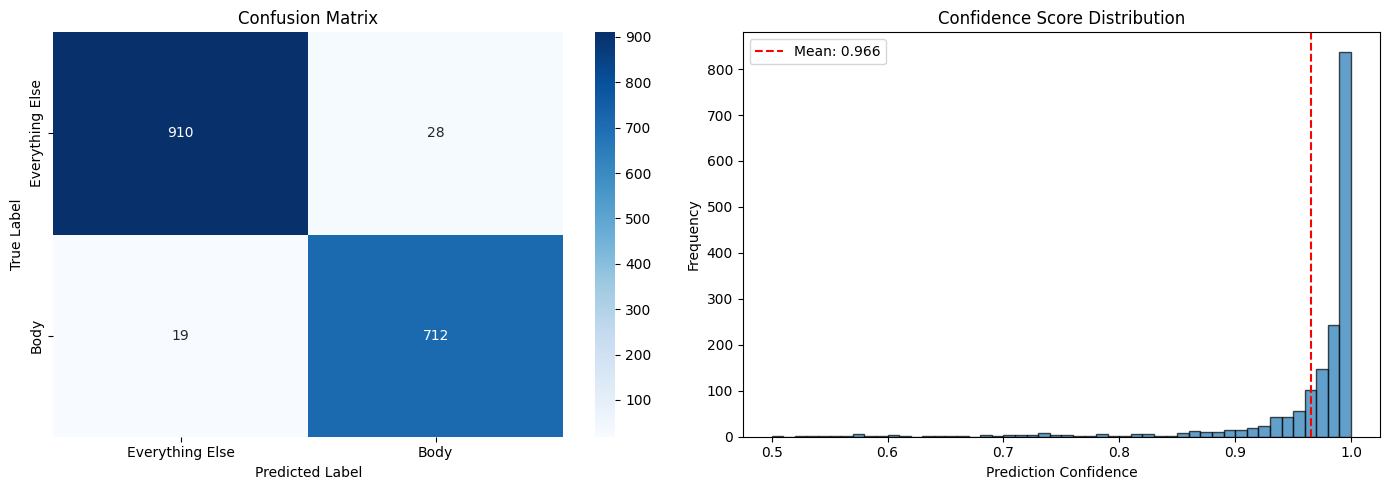


Confidence Filtering Evaluation:
Threshold    Samples      Accuracy     Coverage    
--------------------------------------------------
0.50         1669         0.9718       1.0000      
0.60         1653         0.9764       0.9904      
0.70         1635         0.9804       0.9796      
0.80         1598         0.9862       0.9575      
0.90         1530         0.9935       0.9167      
0.95         1388         0.9964       0.8316      


In [8]:
# 7. Stage 1 Evaluation
# Evaluate Stage 1 model performance

def evaluate_stage1(results, model_name, X_test, y_test):
    """Evaluate Stage 1 model with detailed metrics"""
    print("\n" + "=" * 70)
    print(f"STAGE 1 EVALUATION: {model_name.upper()}")
    print("=" * 70)
    
    clf = results[model_name]['classifier']
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Everything Else', 'Body']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                {'Everything Else':>15} {'Body':>10}")
    print(f"Actual Everything Else {cm[0,0]:>10} {cm[0,1]:>10}")
    print(f"       Body            {cm[1,0]:>10} {cm[1,1]:>10}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Everything Else', 'Body'],
                yticklabels=['Everything Else', 'Body'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Confidence distribution
    confidences = np.max(y_pred_proba, axis=1)
    axes[1].hist(confidences, bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Prediction Confidence')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Confidence Score Distribution')
    axes[1].axvline(confidences.mean(), color='r', linestyle='--', 
                     label=f'Mean: {confidences.mean():.3f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    # Confidence filtering evaluation
    print("\nConfidence Filtering Evaluation:")
    print(f"{'Threshold':<12} {'Samples':<12} {'Accuracy':<12} {'Coverage':<12}")
    print("-" * 50)
    
    for threshold in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        mask = confidences >= threshold
        if np.sum(mask) > 0:
            acc = accuracy_score(y_test[mask], y_pred[mask])
            coverage = np.sum(mask) / len(y_test)
            print(f"{threshold:<12.2f} {np.sum(mask):<12} {acc:<12.4f} {coverage:<12.4f}")
    
    return y_pred, y_pred_proba

# Evaluate best Stage 1 model
y_pred_s1, y_pred_proba_s1 = evaluate_stage1(stage1_results, best_stage1_model, X_test_s1, y_test_s1)


In [9]:
# 8. Prepare Data for Stage 2: Base vs Rim vs Appendage
# Filter to only "everything else" samples (base, rim, appendage)

def prepare_stage2_data(labels, features, original_labels):
    """Prepare data for Stage 2: base vs rim vs appendage"""
    # Filter to only non-body samples
    stage2_indices = [i for i, label in enumerate(labels) if label != 'body']
    
    stage2_features = features[stage2_indices]
    stage2_labels = [labels[i] for i in stage2_indices]  # Should be base, rim, or appendage
    stage2_original_labels = [original_labels[i] for i in stage2_indices]
    
    # Encode labels: base=0, rim=1, appendage=2
    label_encoder = LabelEncoder()
    stage2_labels_encoded = label_encoder.fit_transform(stage2_labels)
    
    print(f"\nStage 2 Data Preparation:")
    print(f"  Total samples: {len(stage2_labels)}")
    print(f"  Base: {np.sum(stage2_labels_encoded == 0)}")
    print(f"  Rim: {np.sum(stage2_labels_encoded == 1)}")
    print(f"  Appendage: {np.sum(stage2_labels_encoded == 2)}")
    print(f"  Label encoder classes: {label_encoder.classes_}")
    
    return stage2_features, stage2_labels_encoded, stage2_original_labels, label_encoder, stage2_indices

# Prepare Stage 2 data
X_s2, y_s2, orig_labels_s2, label_encoder_s2, s2_indices = prepare_stage2_data(
    labels, features, original_labels
)

# Split data for Stage 2 (stratified split)
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_s2, y_s2, test_size=0.2, random_state=42, stratify=y_s2
)

print(f"\nStage 2 Train/Test Split:")
print(f"  Training samples: {len(X_train_s2)}")
print(f"  Test samples: {len(X_test_s2)}")
print(f"  Training - Base: {np.sum(y_train_s2 == 0)}, Rim: {np.sum(y_train_s2 == 1)}, Appendage: {np.sum(y_train_s2 == 2)}")
print(f"  Test - Base: {np.sum(y_test_s2 == 0)}, Rim: {np.sum(y_test_s2 == 1)}, Appendage: {np.sum(y_test_s2 == 2)}")



Stage 2 Data Preparation:
  Total samples: 4688
  Base: 300
  Rim: 666
  Appendage: 3722
  Label encoder classes: ['appendage' 'base' 'rim']

Stage 2 Train/Test Split:
  Training samples: 3750
  Test samples: 938
  Training - Base: 240, Rim: 533, Appendage: 2977
  Test - Base: 60, Rim: 133, Appendage: 745


In [10]:
# 9. Stage 2 Model Training with Hyperparameter Optimization
# Train multiple classifiers for 3-class classification

def get_stage2_param_grids():
    """Define extended hyperparameter grids for Stage 2 classifiers (optimized for speed, same as Stage 1)"""
    param_grids = {}
    
    # Logistic Regression - optimized grid
    param_grids['logistic_regression'] = {
        'C': np.logspace(-2, 2, 9),  # 0.01 to 100 (reduced from 13 to 9)
        'penalty': ['l2', 'elasticnet'],  # Removed 'l1' to reduce combinations
        'solver': ['lbfgs', 'saga'],  # Removed 'liblinear'
        'max_iter': [1000],  # Single value
        'class_weight': ['balanced', None]
    }
    
    # SVM - Linear - optimized grid
    param_grids['svm_linear'] = {
        'C': np.logspace(-2, 2, 9),  # Reduced from 13 to 9
        'class_weight': ['balanced', None]
    }
    
    # SVM - RBF - optimized grid
    param_grids['svm_rbf'] = {
        'C': np.logspace(-1, 3, 9),  # Reduced from 13 to 9
        'gamma': ['scale', 'auto'] + list(np.logspace(-3, 0, 4)),  # Reduced from 6 to 4
        'class_weight': ['balanced', None]
    }
    
    # Random Forest - minimal grid (RF is very slow, using minimal config)
    # Option: Skip Random Forest by commenting out or set SKIP_RANDOM_FOREST=True
    param_grids['random_forest'] = {
        'n_estimators': [200],  # Single value - 200 trees is usually sufficient
        'max_depth': [20],  # Single value - prevents overfitting and speeds up
        'min_samples_split': [2],  # Single value
        'min_samples_leaf': [1],  # Single value
        'max_features': ['sqrt'],  # Single value (most common and effective)
        'class_weight': ['balanced']  # Single value
    }
    
    # XGBoost (if available) - optimized grid
    if XGBOOST_AVAILABLE:
        param_grids['xgboost'] = {
            'learning_rate': [0.05, 0.1, 0.2],  # Reduced from 4 to 3
            'max_depth': [5, 7, 10],  # Reduced from 4 to 3
            'n_estimators': [200, 300],  # Reduced from 4 to 2
            'subsample': [0.8, 0.9],  # Reduced from 3 to 2
            'colsample_bytree': [0.8, 0.9]  # Reduced from 3 to 2
        }
    
    return param_grids

def train_stage2_models(X_train, y_train, X_test, y_test, cv_folds=3):
    """Train Stage 2 models with hyperparameter optimization (same structure as Stage 1)"""
    print("\n" + "=" * 70)
    print("STAGE 2: Base vs Rim vs Appendage - Model Training")
    print("=" * 70)
    
    param_grids = get_stage2_param_grids()
    results = {}
    
    use_randomized = True
    n_iter_randomized = 25  # Number of iterations for RandomizedSearchCV (reduced for faster training)
    
    # Reduce CV folds for faster training (3 folds is still good for validation)
    cv_folds = 3
    
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Logistic Regression
    print("\n" + "-" * 70)
    print("Training Logistic Regression...")
    print("-" * 70)
    lr = LogisticRegression(random_state=42, multi_class='ovr')
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            lr, param_grids['logistic_regression'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            lr, param_grids['logistic_regression'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['logistic_regression'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred, average='weighted'),
        'test_precision': precision_score(y_test, y_pred, average='weighted'),
        'test_recall': recall_score(y_test, y_pred, average='weighted'),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['logistic_regression']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['logistic_regression']['test_f1']:.4f}")
    
    # SVM Linear
    print("\n" + "-" * 70)
    print("Training Linear SVM...")
    print("-" * 70)
    svm_linear = SVC(kernel='linear', random_state=42, probability=True)
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            svm_linear, param_grids['svm_linear'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            svm_linear, param_grids['svm_linear'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['svm_linear'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred, average='weighted'),
        'test_precision': precision_score(y_test, y_pred, average='weighted'),
        'test_recall': recall_score(y_test, y_pred, average='weighted'),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['svm_linear']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['svm_linear']['test_f1']:.4f}")
    
    # SVM RBF
    print("\n" + "-" * 70)
    print("Training RBF SVM...")
    print("-" * 70)
    svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
    
    if use_randomized:
        grid_search = RandomizedSearchCV(
            svm_rbf, param_grids['svm_rbf'], 
            cv=skf, scoring='balanced_accuracy', 
            n_iter=n_iter_randomized, random_state=42, verbose=1
        )
    else:
        grid_search = GridSearchCV(
            svm_rbf, param_grids['svm_rbf'], 
            cv=skf, scoring='balanced_accuracy', 
            verbose=1
        )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test)
    y_pred_proba = best_clf.predict_proba(X_test)
    
    results['svm_rbf'] = {
        'classifier': best_clf,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred, average='weighted'),
        'test_precision': precision_score(y_test, y_pred, average='weighted'),
        'test_recall': recall_score(y_test, y_pred, average='weighted'),
        'train_time': train_time,
        'predict_proba': y_pred_proba
    }
    
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy: {results['svm_rbf']['test_accuracy']:.4f}")
    print(f"  Test F1: {results['svm_rbf']['test_f1']:.4f}")
    
    # Random Forest (can be skipped - set SKIP_RANDOM_FOREST=True to skip)
    SKIP_RANDOM_FOREST = True  # Set to True to skip Random Forest (it's slow)
    
    if not SKIP_RANDOM_FOREST:
        print("\n" + "-" * 70)
        print("Training Random Forest...")
        print("-" * 70)
        print("  Note: Random Forest is slow. Using minimal grid with single values.")
        rf = RandomForestClassifier(random_state=42)
        
        # For Random Forest, use even fewer iterations since grid is already minimal
        rf_n_iter = 10  # Only 10 iterations for RF (grid has few combinations anyway)
        
        if use_randomized:
            grid_search = RandomizedSearchCV(
                rf, param_grids['random_forest'], 
                cv=skf, scoring='balanced_accuracy', 
                n_iter=rf_n_iter, random_state=42, verbose=1
            )
        else:
            grid_search = GridSearchCV(
                rf, param_grids['random_forest'], 
                cv=skf, scoring='balanced_accuracy', 
                verbose=1
            )
        
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        best_clf = grid_search.best_estimator_
        y_pred = best_clf.predict(X_test)
        y_pred_proba = best_clf.predict_proba(X_test)
        
        results['random_forest'] = {
            'classifier': best_clf,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred, average='weighted'),
            'test_precision': precision_score(y_test, y_pred, average='weighted'),
            'test_recall': recall_score(y_test, y_pred, average='weighted'),
            'train_time': train_time,
            'predict_proba': y_pred_proba
        }
        
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Test Accuracy: {results['random_forest']['test_accuracy']:.4f}")
        print(f"  Test F1: {results['random_forest']['test_f1']:.4f}")
    else:
        print("\n" + "-" * 70)
        print("Skipping Random Forest (SKIP_RANDOM_FOREST=True)")
        print("-" * 70)
    
    # XGBoost (if available)
    if XGBOOST_AVAILABLE:
        print("\n" + "-" * 70)
        print("Training XGBoost...")
        print("-" * 70)
        xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
        
        if use_randomized:
            grid_search = RandomizedSearchCV(
                xgb_clf, param_grids['xgboost'], 
                cv=skf, scoring='balanced_accuracy', 
                n_iter=n_iter_randomized, random_state=42, verbose=1
            )
        else:
            grid_search = GridSearchCV(
                xgb_clf, param_grids['xgboost'], 
                cv=skf, scoring='balanced_accuracy', 
                verbose=1
            )
        
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        best_clf = grid_search.best_estimator_
        y_pred = best_clf.predict(X_test)
        y_pred_proba = best_clf.predict_proba(X_test)
        
        results['xgboost'] = {
            'classifier': best_clf,
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred, average='weighted'),
            'test_precision': precision_score(y_test, y_pred, average='weighted'),
            'test_recall': recall_score(y_test, y_pred, average='weighted'),
            'train_time': train_time,
            'predict_proba': y_pred_proba
        }
        
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Test Accuracy: {results['xgboost']['test_accuracy']:.4f}")
        print(f"  Test F1: {results['xgboost']['test_f1']:.4f}")
    
    # Summary
    print("\n" + "=" * 70)
    print("STAGE 2 MODEL COMPARISON")
    print("=" * 70)
    print(f"{'Model':<20} {'CV Score':<12} {'Test Acc':<12} {'Test F1':<12} {'Time (s)':<12}")
    print("-" * 70)
    
    best_model_name = None
    best_score = -1
    
    for model_name, result in results.items():
        print(f"{model_name:<20} {result['best_cv_score']:<12.4f} {result['test_accuracy']:<12.4f} "
              f"{result['test_f1']:<12.4f} {result['train_time']:<12.2f}")
        if result['best_cv_score'] > best_score:
            best_score = result['best_cv_score']
            best_model_name = model_name
    
    print(f"\n✓ Best Stage 2 Model: {best_model_name} (CV Score: {best_score:.4f})")
    
    return results, best_model_name

# Train Stage 2 models (using 3-fold CV for faster training)
stage2_results, best_stage2_model = train_stage2_models(
    X_train_s2, y_train_s2, X_test_s2, y_test_s2, cv_folds=3
)

# Save best Stage 2 model
best_clf_s2 = stage2_results[best_stage2_model]['classifier']
best_params_s2 = stage2_results[best_stage2_model]['best_params']

joblib.dump(best_clf_s2, f"models/type_stage2_{best_stage2_model}_optimized.pkl")
joblib.dump(best_params_s2, f"models/type_stage2_{best_stage2_model}_params.pkl")
print(f"\n✓ Saved Stage 2 model: models/type_stage2_{best_stage2_model}_optimized.pkl")



STAGE 2: Base vs Rim vs Appendage - Model Training

----------------------------------------------------------------------
Training Logistic Regression...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits


g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was d

  Best CV Score: 0.9095
  Test Accuracy: 0.9670
  Test F1: 0.9675

----------------------------------------------------------------------
Training Linear SVM...
----------------------------------------------------------------------
Fitting 3 folds for each of 18 candidates, totalling 54 fits


g:\GitHub\ascota\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=25. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best CV Score: 0.9121
  Test Accuracy: 0.9584
  Test F1: 0.9595

----------------------------------------------------------------------
Training RBF SVM...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Best CV Score: 0.9301
  Test Accuracy: 0.9627
  Test F1: 0.9639

----------------------------------------------------------------------
Skipping Random Forest (SKIP_RANDOM_FOREST=True)
----------------------------------------------------------------------

----------------------------------------------------------------------
Training XGBoost...
----------------------------------------------------------------------
Fitting 3 folds for each of 25 candidates, totalling 75 fits
  Best CV Score: 0.8317
  Test Accuracy: 0.9755
  Test F1: 0.9750

STAGE 2 MODEL COMPARISON
Model                CV Score     Test Acc     Test F1      Time (s)    
---------------------------------------------------------------


STAGE 2 EVALUATION: SVM_RBF

Classification Report:
              precision    recall  f1-score   support

   appendage       0.97      0.97      0.97        60
        base       0.82      0.97      0.89       133
         rim       0.99      0.96      0.98       745

    accuracy                           0.96       938
   macro avg       0.93      0.97      0.94       938
weighted avg       0.97      0.96      0.96       938


Confusion Matrix:
                 Predicted
                   appendage        base         rim
Actual appendage           58           2           0
Actual     base            0         129           4
Actual      rim            2          27         716


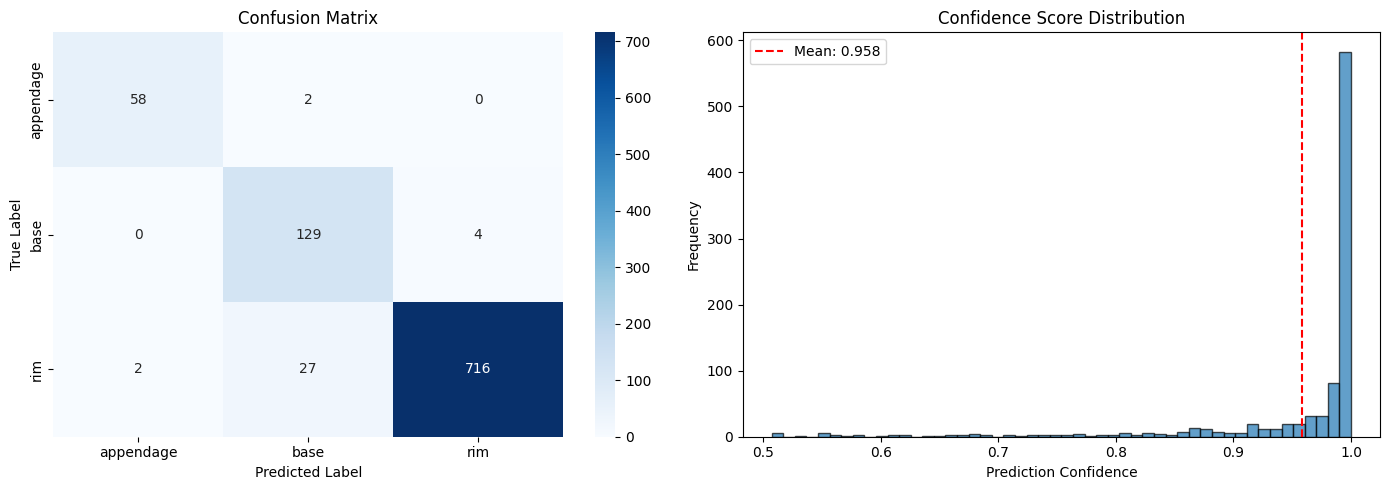


Confidence Filtering Evaluation:
Threshold    Samples      Accuracy     Coverage    
--------------------------------------------------
0.50         938          0.9627       1.0000      
0.60         919          0.9739       0.9797      
0.70         900          0.9822       0.9595      
0.80         881          0.9898       0.9392      
0.90         817          0.9939       0.8710      
0.95         749          0.9960       0.7985      


In [11]:
# 10. Stage 2 Evaluation
# Evaluate Stage 2 model performance

def evaluate_stage2(results, model_name, X_test, y_test, label_encoder):
    """Evaluate Stage 2 model with detailed metrics"""
    print("\n" + "=" * 70)
    print(f"STAGE 2 EVALUATION: {model_name.upper()}")
    print("=" * 70)
    
    clf = results[model_name]['classifier']
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)
    
    class_names = label_encoder.classes_
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(f"                 Predicted")
    header = "                "
    for name in class_names:
        header += f"{name:>12}"
    print(header)
    for i, name in enumerate(class_names):
        row = f"Actual {name:>8} "
        for j in range(len(class_names)):
            row += f"{cm[i, j]:>12}"
        print(row)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Confidence distribution
    confidences = np.max(y_pred_proba, axis=1)
    axes[1].hist(confidences, bins=50, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Prediction Confidence')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Confidence Score Distribution')
    axes[1].axvline(confidences.mean(), color='r', linestyle='--', 
                     label=f'Mean: {confidences.mean():.3f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    # Confidence filtering evaluation
    print("\nConfidence Filtering Evaluation:")
    print(f"{'Threshold':<12} {'Samples':<12} {'Accuracy':<12} {'Coverage':<12}")
    print("-" * 50)
    
    for threshold in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        mask = confidences >= threshold
        if np.sum(mask) > 0:
            acc = accuracy_score(y_test[mask], y_pred[mask])
            coverage = np.sum(mask) / len(y_test)
            print(f"{threshold:<12.2f} {np.sum(mask):<12} {acc:<12.4f} {coverage:<12.4f}")
    
    return y_pred, y_pred_proba

# Evaluate best Stage 2 model
y_pred_s2, y_pred_proba_s2 = evaluate_stage2(
    stage2_results, best_stage2_model, X_test_s2, y_test_s2, label_encoder_s2
)


In [19]:
# 11. Stage 3: GPT-4o Integration (Experimental)
# Use Azure GPT-4o to classify appendage subtypes

def prepare_image_for_gpt4o(image, max_size=512):
    """Resize image and convert to base64 for GPT-4o"""
    # Resize while maintaining aspect ratio
    image.thumbnail((max_size, max_size), Image.Resampling.LANCZOS)
    
    # Convert to base64
    buffered = BytesIO()
    image.save(buffered, format="PNG")
    img_base64 = base64.b64encode(buffered.getvalue()).decode('utf-8')
    
    return img_base64

def classify_appendage_with_gpt4o(image, azure_endpoint=None, api_key=None, api_version="2024-02-15-preview"):
    """Classify appendage using Azure GPT-4o with vision"""
    
    if not AZURE_OPENAI_AVAILABLE:
        print("Azure OpenAI SDK not available. Skipping GPT-4o classification.")
        return None, None
    
    if azure_endpoint is None or api_key is None:
        print("Azure OpenAI credentials not provided. Please set azure_endpoint and api_key.")
        print("Skipping GPT-4o classification for now.")
        return None, None
    
    try:
        # Prepare image
        img_base64 = prepare_image_for_gpt4o(image, max_size=512)
        
        # Initialize Azure OpenAI client
        client = AzureOpenAI(
            azure_endpoint=azure_endpoint,
            api_key=api_key,
            api_version=api_version
        )
        
        # Create prompt
        prompt = """Classify this pottery sherd appendage into one of the following categories:
- lid
- rim-handle
- spout
- rounded
- body-decorated
- tile

Please respond with:
1. The classification label (one of the categories above)
2. Your confidence level (0.0 to 1.0)
3. A brief explanation of why you chose this classification

Format your response as:
Label: <category>
Confidence: <number>
Explanation: <brief explanation>"""
        
        # Call GPT-4o
        response = client.chat.completions.create(
            model="gpt-4o",  # Adjust model name if needed
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/png;base64,{img_base64}"
                            }
                        }
                    ]
                }
            ],
            max_tokens=500
        )
        
        # Parse response
        response_text = response.choices[0].message.content
        
        # Extract label and confidence
        label = None
        confidence = None
        explanation = None
        
        for line in response_text.split('\n'):
            if line.startswith('Label:'):
                label = line.split('Label:')[1].strip().lower()
            elif line.startswith('Confidence:'):
                try:
                    confidence = float(line.split('Confidence:')[1].strip())
                except:
                    confidence = 0.5  # Default
            elif line.startswith('Explanation:'):
                explanation = line.split('Explanation:')[1].strip()
        
        # Validate label
        valid_labels = ['lid', 'rim-handle', 'spout', 'rounded', 'body-decorated', 'tile']
        if label not in valid_labels:
            # Try to find label in response
            for valid_label in valid_labels:
                if valid_label in response_text.lower():
                    label = valid_label
                    break
        
        return label, confidence
    
    except Exception as e:
        print(f"Error calling GPT-4o: {e}")
        return None, None

# Test GPT-4o classification (requires Azure credentials)
# Uncomment and provide credentials to test
AZURE_ENDPOINT = "https://engineering-and-archaeology.openai.azure.com/"
AZURE_API_KEY = "8df98ecfe8db47bd8ff11e0b7033a273"

# Get appendage test images
appendage_test_indices = [i for i, pred in enumerate(y_pred_s2) 
                         if pred == 2 and i < len(X_test_s2)]  # Class 2 = appendage
if len(appendage_test_indices) > 0:
    test_idx = appendage_test_indices[0]
    test_image_idx = s2_indices[X_test_s2.index(test_idx)] if hasattr(X_test_s2, 'index') else test_idx
    test_image = images[test_image_idx] if test_image_idx < len(images) else images[0]
    
    print("Testing GPT-4o classification on sample appendage image...")
    label, confidence = classify_appendage_with_gpt4o(test_image, AZURE_ENDPOINT, AZURE_API_KEY)
    print(f"GPT-4o Result: {label} (confidence: {confidence})")


Testing GPT-4o classification on sample appendage image...
GPT-4o Result: tile (confidence: 0.85)
